In [41]:
import pandas as pd
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV,train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score,precision_recall_curve
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectFromModel
import numpy as np

In [30]:
df=pd.read_csv('processed_attrition_data.csv')
df.head()
df.shape



(1470, 34)

In [31]:
encoder=LabelEncoder()
y=encoder.fit_transform(df['Attrition'])
y

array([1, 0, 1, ..., 0, 0, 0], shape=(1470,))

In [44]:
rawX = df.drop(columns=['Attrition'])

In [45]:
x=pd.get_dummies(rawX,drop_first=True)

In [34]:
x_test,x_train,y_test,y_train=train_test_split(x,y,stratify=y,test_size=0.2,random_state=25)

In [35]:
smote=SMOTE(random_state=25)
X_train_smote,y_train_smote=smote.fit_resample(x_train,y_train)


In [36]:

# Train a quick base model to figure out which columns are statistically useless.
base_rf=RandomForestClassifier(n_estimators=100,random_state=25)
base_rf.fit(X_train_smote,y_train_smote)

# Keep only the features that perform above the 'median' importance level.
selector=SelectFromModel(base_rf, prefit=True, threshold="median")
X_train_clean=selector.transform(X_train_smote)
X_test_clean=selector.transform(x_test)

kept_features = x_train.columns[selector.get_support()]

/home/nakul09/Prescriptive_AI_HR_Decision_Engine/hrde1/lib/python3.12/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
/home/nakul09/Prescriptive_AI_HR_Decision_Engine/hrde1/lib/python3.12/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


In [37]:
rfc=RandomForestClassifier(random_state=25)

param_grid = {

    # Number of trees
    "n_estimators": [100, 200, 300, 500, 800],

    # Maximum depth of each tree
    "max_depth": [None, 10, 20, 30, 40, 50],

    # Minimum samples required to split an internal node
    "min_samples_split": [2, 5, 10, 15, 20],

    # Minimum samples required at a leaf node
    "min_samples_leaf": [1, 2, 4, 6, 8],

    # Number of features considered for each split
    "max_features": ["sqrt", "log2", None],

    # Whether bootstrap samples are used
    "bootstrap": [True, False],

    # Split criterion
    "criterion": ["gini", "entropy", "log_loss"],

    # Maximum number of leaf nodes
    "max_leaf_nodes": [None, 20, 40, 60, 80],

    # Minimum weighted fraction at leaf
    "min_weight_fraction_leaf": [0.0, 0.01, 0.02],

    # Minimum impurity decrease required to split
    "min_impurity_decrease": [0.0, 0.001, 0.01],

    # Class weighting
    "class_weight": ["balanced", "balanced_subsample"]
}

random_search = RandomizedSearchCV(
                estimator=rfc,
                param_distributions=param_grid, 
                n_iter=100,                     
                cv=5,
                n_jobs=-1,
                verbose=2,
                scoring='roc_auc',
                random_state=25
)
random_search.fit(X_train_clean,y_train_smote)
random_search.best_params_


Fitting 5 folds for each of 100 candidates, totalling 500 fits


[CV] END bootstrap=False, class_weight=balanced_subsample, criterion=log_loss, max_depth=10, max_features=log2, max_leaf_nodes=40, min_impurity_decrease=0.001, min_samples_leaf=2, min_samples_split=15, min_weight_fraction_leaf=0.02, n_estimators=200; total time=   0.3s
[CV] END bootstrap=False, class_weight=balanced, criterion=gini, max_depth=None, max_features=log2, max_leaf_nodes=60, min_impurity_decrease=0.0, min_samples_leaf=2, min_samples_split=5, min_weight_fraction_leaf=0.0, n_estimators=200; total time=   0.3s
[CV] END bootstrap=False, class_weight=balanced_subsample, criterion=log_loss, max_depth=10, max_features=log2, max_leaf_nodes=40, min_impurity_decrease=0.001, min_samples_leaf=2, min_samples_split=15, min_weight_fraction_leaf=0.02, n_estimators=200; total time=   0.3s
[CV] END bootstrap=False, class_weight=balanced_subsample, criterion=log_loss, max_depth=10, max_features=log2, max_leaf_nodes=40, min_impurity_decrease=0.001, min_samples_leaf=2, min_samples_split=15, min_

{'n_estimators': 800,
 'min_weight_fraction_leaf': 0.0,
 'min_samples_split': 5,
 'min_samples_leaf': 2,
 'min_impurity_decrease': 0.001,
 'max_leaf_nodes': None,
 'max_features': 'sqrt',
 'max_depth': 20,
 'criterion': 'gini',
 'class_weight': 'balanced',
 'bootstrap': False}

In [42]:
pred=random_search.predict(X_test_clean)
probs=random_search.predict_proba(X_test_clean)[:,1]

precisions,recalls,thresholds=precision_recall_curve(y_test,probs)

# Calculate F1 score for every point (adding a tiny number to prevent divide-by-zero errors)
f1_scores=(2*precisions*recalls)/(precisions+recalls+1e-9)

# Find the threshold that achieved the highest F1 score
best_index=np.argmax(f1_scores)
optimal_threshold = thresholds[best_index]
new_preds=(probs>=optimal_threshold).astype(int)
print(classification_report(y_test,new_preds))

              precision    recall  f1-score   support

           0       0.91      0.88      0.89       986
           1       0.45      0.53      0.49       190

    accuracy                           0.82      1176
   macro avg       0.68      0.70      0.69      1176
weighted avg       0.83      0.82      0.83      1176



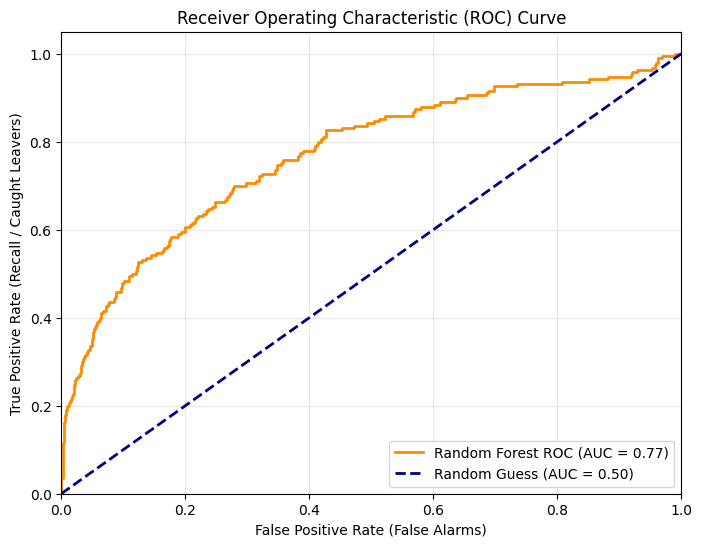

In [43]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 1. Calculate the points of the curve
# This tests every possible threshold and calculates the False Alarms (fpr) and Caught Leavers (tpr)
fpr, tpr, thresholds = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

# 2. Set up the visual canvas
plt.figure(figsize=(8, 6))

# 3. Draw the actual model's curve (Orange line)
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'Random Forest ROC (AUC = {roc_auc:.2f})')

# 4. Draw the "Useless Coin Flip" line for comparison (Dashed blue line)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
         label='Random Guess (AUC = 0.50)')

# 5. Format the labels and grid
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (False Alarms)')
plt.ylabel('True Positive Rate (Recall / Caught Leavers)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

# 6. Display the graph
plt.show()

In [46]:
df.sample(5)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Annual_CTC_LPA,Comp_Ratio,Overwork_Strain,Role_Friction
128,22,No,Travel_Rarely,594,Research & Development,2,1,Technical Degree,3,Male,...,2,3,2,1,2,1,6.43365,0.874220,2.0,1.2
1120,38,No,Travel_Rarely,437,Sales,16,3,Life Sciences,2,Female,...,5,4,3,2,1,2,10.70490,0.673728,16.0,1.0
140,32,Yes,Travel_Rarely,1033,Research & Development,9,3,Medical,1,Female,...,2,4,5,4,0,4,10.71000,1.455301,9.0,1.2
98,58,No,Travel_Rarely,682,Sales,10,4,Medical,4,Male,...,1,2,37,10,1,8,35.37360,2.226288,10.0,1.0
1065,55,No,Travel_Rarely,1229,Research & Development,4,4,Life Sciences,4,Male,...,2,3,3,2,1,2,10.28925,0.592424,8.0,1.2
